# Homework 4

## Coding


In [ ]:
import math
import requests
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

### 7.1

In [135]:
# loading the dataset
data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
with open("input.txt", 'w') as f:
    f.write(requests.get(data_url).text)

with open("input.txt", 'r') as f:
    dataset = f.read()
print(f"length of dataset in characters: {len(data):,}")

length of dataset in characters: 1,115,394


In [136]:
# global variables
unique_characters = sorted(list(set(dataset)))
print(f"number of unique characters: {len(unique_characters)}")
print(f"characters: {''.join(unique_characters)}")

batch_size = 12
block_size = 64
n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.0

# create mapping
string_to_int = {}
int_to_string = {}
for i,ch in enumerate(unique_characters):
    string_to_int[ch] = i
    int_to_string[i] = ch

print(f"String to Int mapping: {string_to_int}")
print(f"Int to String mapping: {int_to_string}")

number of unique characters: 65
characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
String to Int mapping: {'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}
Int to String mapping: {0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: '

In [137]:
# part 1 of 7.1
def encode(word: str) -> list[int]:
    """Convert string to integer"""
    converted = []
    for char in word:
        if char not in string_to_int.keys():
            raise RuntimeError(f"character didn't exist: {char}")
        converted.append(string_to_int[char])
    return converted

def decode(integers: list[int]) -> str:
    """Convert list of integers into a string"""
    converted = []
    for value in integers:
        if value not in int_to_string.keys():
            raise RuntimeError(f"integer didn't exist: {value}")
        converted.append(int_to_string[value])
    return ''.join(converted)

# running tests
test_string1 = "pxwmHDyZEZ"
encoded_test_string1 = encode(test_string1)
decoded_test_string1 = decode(encoded_test_string1)

print(f"Original: {test_string1}")
print(f"Encoded: {encoded_test_string1}")
print(f"Decoded: {decoded_test_string1}")

Original: pxwmHDyZEZ
Encoded: [54, 62, 61, 51, 20, 16, 63, 38, 17, 38]
Decoded: pxwmHDyZEZ


In [ ]:
# part 2 of 7.1

# encode current dataset
encoded_dataset = torch.tensor(encode(dataset), dtype=torch.long)

# training / test data split
split = int(0.9 * len(dataset))
train_split = encoded_dataset[:split]
test_split = encoded_dataset[split:]

def get_batch(split: str):
    """Create batch for context size of t"""
    if split.lower() == "train":
        data_source = train_split
    elif split.lower() == "test":
        data_source = test_split
    else:
        raise RuntimeError(f"Invalid split received: {split}, must be train or test")
    
    # random starting position
    indexes = torch.randint(len(data_source) - block_size, (batch_size,))

    # batch creation
    x = []
    y = []
    for i in indexes:
        x.append(data_source[i : i + block_size])
        y.append(data_source[i + 1 : i + block_size + 1])

    x = torch.stack(x)
    y = torch.stack(y)

    return x, y

In [139]:
# part 3 of 7.1
x, y = get_batch("train")

assert torch.equal(x[0, 1:], y[0, :-1]) == True

decoded_x1 = decode(x[0].tolist())
decoded_y1 = decode(y[0].tolist())
print(f"Decoded x: {decoded_x1}")
print(f"Decoded y: {decoded_y1}")

Decoded x:  friar
Subtly hath minister'd to have me dead,
Lest in this marr
Decoded y: friar
Subtly hath minister'd to have me dead,
Lest in this marri


### 7.2

In [147]:
class CasualSelfAttention(nn.Module):
    def __init__(self, n_embd: int, n_head: int, dropout: float, block_size: int, bias: bool = False):
        super().__init__()

        self.n_head = n_head
        self.n_embd = n_embd
        self.dropout = dropout
        self.head_dim = n_embd // n_head

        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=bias)

        # output projection
        self.c_proj = nn.Linear(n_embd, n_embd, bias=bias)

        # regularization
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        casual_mask = torch.tril(torch.ones(block_size, block_size))
        self.casual_mask = casual_mask.view(1, 1, block_size, block_size)
        self.register_buffer("bias", self.casual_mask)
    
    def forward(self, x, return_attention: bool =False):
        # batch size, sequence length, embedding dimensionality (n_embd)
        B, T, C = x.size()

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        A = q @ k.transpose(-2, -1)
        A = (A / math.sqrt(self.head_dim))

        p = A.masked_fill(self.casual_mask[:,:,:T,:T] == 0, float('-inf'))
        p = F.softmax(p, dim=-1)

        O = p @ v

        y = O.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        if return_attention:
            return y, p

        return y

In [148]:
# tests
torch.manual_seed(42)

n_embd = 128
n_head = 4
block_size = 64

attention = CausalSelfAttention(
    n_embd=n_embd,
    n_head=n_head,
    dropout=0.0,
    block_size=block_size,
)

attention.eval()

B = 2
T = 8

H = torch.randn(B, T, n_embd)

_, P = attention(H, return_attention=True)
upper_triangle = torch.triu(
    P[0, 0],
    diagonal=1,
)

assert torch.allclose(
    upper_triangle,
    torch.zeros_like(upper_triangle),
)
print("Upper triangle of the attention matrix is all zeros, as expected.")

Upper triangle of the attention matrix is all zeros, as expected.


In [149]:
m = 4

H2 = H.clone()
H2[:, m:] = torch.randn_like(H2[:, m:])

assert torch.equal(
    H[:, :m],
    H2[:, :m],
)

assert not torch.equal(
    H[:, m:],
    H2[:, m:],
)

with torch.no_grad():
    output1 = attention(H)
    output2 = attention(H2)

assert torch.allclose(
    output1[:, :m],
    output2[:, :m],
    atol=1e-6,
    rtol=1e-5,
)
print("Output for the first m tokens is the same for both inputs, as expected.")

Output for the first m tokens is the same for both inputs, as expected.


### 7.3

In [ ]:
from torch.cuda import temperature
class MLP(nn.Module):
    def __init__(self, n_embd: int, dropout: float, bias: bool = False):
        super().__init__()
        self.c_fc = nn.Linear(n_embd, 4 * n_embd, bias=bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * n_embd, n_embd, bias=bias)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):
    def __init__(self, n_embd: int, n_head: int, dropout: float, block_size: int, bias: bool = False):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd, bias=bias)
        self.ln_2 = nn.LayerNorm(n_embd)

        self.attn = CasualSelfAttention(
            n_embd=n_embd, 
            n_head=n_head, 
            dropout=dropout, 
            block_size=block_size, 
            bias=bias
        )

        self.mlp = MLP(
            n_embd=n_embd,
            dropout=dropout,
            bias=bias
        )
    
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class GPT(nn.Module):
    def __init__(self, vocab_size: int, block_size: int, n_layers: int, n_embd: int, n_head: int, dropout: int, bias: bool = False):
        super().__init__()
        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_embd = n_embd

        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.positional_embedding = nn.Embedding(block_size, n_embd)
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            Block(
                n_embd=n_embd,
                n_head=n_head,
                dropout=dropout,
                block_size=block_size,
                bias=bias
            )
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(n_embd, bias=bias)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=bias)

    def forward(self, idx, targets = None):
        B, T = idx.size()

        if T > self.block_size:
            raise ValueError(f"Cannot forward sequence of length {T}, block size is only {self.block_size}")
        
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        
        token_embeddings = self.token_embedding(idx)
        positional_embeddings = self.positional_embedding(pos)
        x = self.dropout(token_embeddings + positional_embeddings)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.reshape(B * T, self.vocab_size), targets.reshape(B * T))
        else:
            logits = self.lm_head(x[:, -1:, :])
            loss = None
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k: int = None):
      for _ in range(max_new_tokens):
        idx_cond = idx if idx.size(1) <= self.block_size else idx[:, -self.block_size:]
        logits, _ = self(idx_cond)
        logits = logits[:, -1, :] / temperature

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("Inf")

        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
      return idx

Number of params: 812928
Device: cpu
Step    0 | lr 0.0003 | train loss 4.3288 | val loss 4.3387
Step  200 | lr 0.0003 | train loss 2.5517 | val loss 2.5626
Step  400 | lr 0.0003 | train loss 2.4450 | val loss 2.4385
Step  600 | lr 0.0003 | train loss 2.3342 | val loss 2.3554
Step  800 | lr 0.0003 | train loss 2.2285 | val loss 2.2724
Step 1000 | lr 0.0003 | train loss 2.1750 | val loss 2.1926
Step 1200 | lr 0.0003 | train loss 2.0798 | val loss 2.1246
Step 1400 | lr 0.0003 | train loss 2.0568 | val loss 2.0809
Step 1600 | lr 0.0003 | train loss 2.0013 | val loss 2.0597
Step 1800 | lr 0.0003 | train loss 1.9563 | val loss 2.0139
Step 2000 | lr 0.0003 | train loss 1.9187 | val loss 1.9808
Step 2200 | lr 0.0003 | train loss 1.8565 | val loss 1.9789
Step 2400 | lr 0.0003 | train loss 1.8106 | val loss 1.9601
Step 2600 | lr 0.0003 | train loss 1.8278 | val loss 1.9504
Step 2800 | lr 0.0003 | train loss 1.7793 | val loss 1.9183


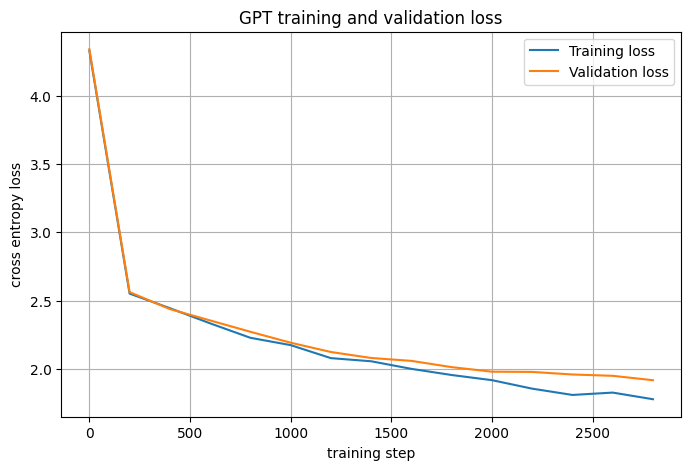

=================== Generated text sample ====================


DUKE VINCENTIO:
Billow it but consting
Entign'd Parwer, wooker bothe ding I I
Would Becimenglion.

MONIUS:
It nate, to our speate baint stipts.

Thetere:
Noo is conting the a fore you grie?

Gist MANIENEN:
I curno, trous for art or troing
If KisRY Mithan tand the dabmerofe, and actiens
Male! to erest pase presslide, in, eve everond,
Lood:
May sencingts whigh juenlestmen that speak hum:
For Hencee is womed baye mist of it thee:
Murth in our that their.

DULIO:
May that:
Romes:
Warh, my rebes, th


In [ ]:
model = GPT(
    vocab_size=len(unique_characters),
    block_size=block_size,
    n_layers=n_layer,
    n_head=n_head,
    n_embd=n_embd,
    dropout=dropout
)

num_of_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)
print(f"Number of params: {num_of_params}")

device = ("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Device: {device}")

lr = 3e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

@torch.no_grad()
def estimate_loss(eval_iters: int = 200):
    out = {}
    model.eval()
    for split in ['train', 'test']:
        losses = []
        for _ in range(eval_iters):
            xb, yb = get_batch(split)

            xb = xb.to(device)
            yb = yb.to(device)

            _, loss = model(xb, yb)
            losses.append(loss.item())

        out[split] = sum(losses) / len(losses)
    model.train()
    return out

# training loop
max_iters = 3000
eval_interval = 200
eval_iters = 20
training_steps = []
training_losses = []
validation_losses = []

model.train()

for step in range(max_iters):
    if step % eval_interval == 0:
        losses = estimate_loss(eval_iters)

        training_steps.append(step)
        training_losses.append(losses["train"])
        validation_losses.append(losses["test"])

        print(f"Step {step:4d} | lr {lr} | train loss {losses["train"]:.4f} | val loss {losses['test']:.4f}")
    xb, yb = get_batch("train")
    xb = xb.to(device)
    yb = yb.to(device)

    logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# end result plot
plt.figure(figsize=(8,5))
plt.plot(
    training_steps,
    training_losses,
    label="Training loss",
)

plt.plot(
    training_steps,
    validation_losses,
    label="Validation loss"
)

plt.xlabel("training step")
plt.ylabel("cross entropy loss")
plt.title("GPT training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

print(f"=================== Generated text sample ====================")
model.eval()
start_tokens = torch.tensor([encode("\n")], dtype=torch.long, device=device)
generated = model.generate(start_tokens, max_new_tokens=500)
decoded = decode(generated[0].tolist())
print(decoded)

### 7.4

In [ ]:
torch.manual_seed(42)
model.eval()
prompt = encode("ROMEO:\n")

print("\n" + "=" * 70)
print("TEMPERATURE = 0.7, TOP_K = 10")
print("=" * 70)
start_tokens = torch.tensor([prompt], dtype=torch.long, device=device)
generated = model.generate(start_tokens, max_new_tokens=500, temperature=0.7, top_k=10)
decoded = decode(generated[0].tolist())
print(decoded)

print("\n" + "=" * 70)
print("TEMPERATURE = 1.2, TOP_K = 10")
print("=" * 70)
start_tokens = torch.tensor([prompt], dtype=torch.long, device=device)
generated = model.generate(start_tokens, max_new_tokens=500, temperature=0.7, top_k=10)
decoded = decode(generated[0].tolist())
print(decoded)


TEMPERATURE = 0.7, TOP_K = 10
ROMEO:
His lord shall and we my consure, thou to been.

CARIOLAND:
Neep and the freath the man, the my heart,
For the panerest theme thee to him burn his bear
Any hare son the his not hearts buth.

POMINIUS:
As have is think make wome herve and that be than beffore
In a dissed to the thought be the these with. Come,
Then friecter the come to the was not strist
To bist she marking of the with wis fath ace
As I the make to main this and with their my sould not man,
And an the that gruee heart and may hav

TEMPERATURE = 1.2, TOP_K = 10
ROMEO:
A lord his to stand he will she he behall take me pay
The stake on this drothere will no seave to the be
To grave tise on made it the centring his deed and spite and that,
Intummich the scall strutting bother the forth heart,
Which the pare the faster the priet to me
Thought seath and thing the firth this do this with and
That fiend the would at tand may prise
The purdeed is so to the cried thee heave.

MARGARENGE:
You 

With top_k fixed at 10, the temperature changes how strongly the model favored its most likely character choices. With temperature=0.7, the generated text results in text that are more common and the sentence structure makes more sense. It uses a lot more common words such as "the", "his", "heart", and "that". It follows more of the Shakespeare-like dialogue formatting consistently. With temperature=1.2, the text is more varied and unpredictable. There are a lot more unusual invented words and names and sentences are not as understandable. There is a wide variety in word choice selection. This shows that the lower temperature provided a much better output for the generated text.

## Theory

### 7.6
Casual attention mask can be seen as the following matrix
$$
\begin{bmatrix}
1 & 0 & 0 & 0 \\
1 & 1 & 0 & 0 \\
1 & 1 & 1 & 0 \\
1 & 1 & 1 & 1
\end{bmatrix}
$$
Each row represents the position being processed and each column represents the position it can attend to. A value of 1 represents that the attentnion is allowed and value 0 represents that the attention is not allowed.

Any entry above the diagonal must be masked because they represent future tokens. Consider the model must predict a token at position i, it cannot be allowed to use tokens for attention at positions greater than i. This is due to the idea that the model will be able to see information that can reveal the answer that it is supposed to predict.  

The model can calculate the outputs at all four positions in one forward pass because the entire training sequence is fully available. Queries, keys, values, and attention scores for every position is calculated using matrix operations. The casual mask ensures that each position only uses itself and any earlier positions for outputs. Hence, calculations can occur in parallel without the information leakage from future tokens. 

### 7.8
The increasing or decreasing of $\tau$ affect the probability of each logit. For decreasing $\tau$, it may lead to more predictable, conservative and repetitive choices in generation due to high logits having more probability than low logit tokens. With increasing $\tau$, the distribution becomes flatter so the generated tokens are more varied and less repetitive since low logit tokens may have greater chance in getting selected. The choice of $\tau$ was definitely reflected in 7.4. As it can be seen with $\tau = 1.2$, the model generated unusual tokens. Whereas, $\tau = 0.7$ produced much more common words and maintaining the formatting that the text is supposed to follow. 

Top-k sampling is keeping only the top k tokens with the largest logits. All others are changed to $- \infty$ to give those tokens a probability of 0. A small value of k usually will produce a safer and more repetitive text due to a smaller amount of possible choices. A larger value of k allows more varied output but also increases the possibility of strange or incorrect choices. In problem 7.4, I chose to keep k constant in both sampling where the effects were not able to be seen. In my generation, the top 10 choices were always considered at every step.